[![Text: CC BY-SA 4.0](https://img.shields.io/badge/text-CC%20BY--SA%204.0-lightgrey.svg)](https://creativecommons.org/licenses/by-sa/4.0/)
[![Code: MIT](https://img.shields.io/badge/code-MIT-yellow.svg)](https://opensource.org/license/mit)

This notebook is part of course materials for CS 545: Machine Learning at
Colorado State University. These notebooks are based on the PyTorch version of
[Dive into Deep Learning](https://d2l.ai) by Aston Zhang, Zachary C. Lipton,
Mu Li and Alexander J. Smola, used under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/) and heavily
modified by [Asa Ben-Hur](https://www.cs.colostate.edu/~asa/) with
[Claude](https://claude.com) AI. The text is released under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/); the code is
released under the [MIT license](https://opensource.org/license/mit).

In [1]:
# render figures as crisp vector graphics (SVG) in the notebook
try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats('svg')
except ImportError:
    pass

import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'   # keep text as text in the SVG

import math
import time
import numpy as np
import torch
import matplotlib.pyplot as plt

# Linear Regression

While many of you have seen linear regression in the context of a statistics course, we will provide a different view of this simple modeling approach, allowing us to develop all the machinery we will need for complex neural networks in a much simpler setup.  Beyond that, there are several good reasons to keep linear regression in mind even once we have learned more sophisiticated model:

* Fast
* Easy to use
* Interpretable
* Basis for many other methods

Regression problems pop up whenever we want to predict a numerical value.
Common examples include predicting prices (of homes, stocks, etc.),
forecasting problems (weather related, business related such as retail demand), science related (e.g. predict properties of molecules, materials etc.) and many others.

**Regression**: Learn a mapping from *feature vectors* to a set of *continuous labels*, i.e. a function

$$ f  : \mathbb{R}^d \longrightarrow \mathbb{R}   $$

Here is an example of linear regression applied to toy data in one dimension:

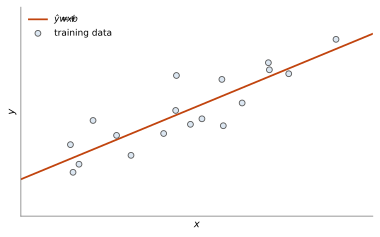

In [2]:
def linreg_fit_figure():
    """A linear fit to one-dimensional toy data."""
    rng = np.random.default_rng(3)
    x = np.sort(rng.uniform(0.4, 5.6, 18))
    y = 1.1 + 0.85 * x + rng.normal(0, 0.85, x.size)
    w, b = np.polyfit(x, y, 1)

    fig, ax = plt.subplots(figsize=(5.4, 3.4))
    grid = np.linspace(0, 6, 2)
    ax.plot(grid, w * grid + b, color='#c1440e', linewidth=1.8, zorder=2,
            label='$ŷ = wx + b$')
    ax.scatter(x, y, s=34, facecolor='#dce7f2', edgecolor='0.35',
               linewidth=0.9, zorder=3, label='training data')
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    ax.set_xlim(0, 6)
    ax.set_ylim(y.min() - 1.5, y.max() + 1.1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(loc='upper left', frameon=False, fontsize=9)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
    for side in ('left', 'bottom'):
        ax.spines[side].set_color('0.5')
    fig.tight_layout()

linreg_fit_figure()

Later in the course, we will introduce classification problems,
where the goal is to predict membership among a set of categories rather than a continuous quantity.


### Example: Predicting house prices

As a running example, suppose that we wish to estimate the house prices in NYC (in dollars)
based on their area (in square feet) distance to the subway (in hundreds of feet).
To develop a model for predicting house prices, we need data,
including the sales price, area, and location for each home.
In the terminology of machine learning,
the dataset is called a *training dataset* or *training set*,
and each row (containing the data corresponding to one sale)
is called an *example* (or *data point*, *instance*, *sample*).
The thing we are trying to predict (price)
is called a *label* (or *target*).
The variables (area and distance)
upon which the predictions are based
are called *features* (or *covariates*).

### A regression model for predicting housing prices

In regression we would like a model that describes how features can be transformed
into an estimate of the target.
The assumption of linearity means that the expected value of the target (price) can be expressed as a weighted sum of the features (area and distance):

$$
\textrm{price} = w_{\textrm{area}} \cdot \textrm{area} + w_{\textrm{dist}} \cdot \textrm{dist} + b. 
$$


Here $w_{\textrm{area}}$ and $w_{\textrm{dist}}$
are called the *weights*, and $b$ is called the *bias*.
The weights determine the influence of each feature on our prediction.
The bias determines the value of the estimate when all features are zero.

Even though we will never see any newly-built homes with precisely zero features,
we still need the bias because it allows us
to express all linear functions of our features
(rather than restricting us to lines that pass through the origin).
Strictly speaking, the above equation is an *affine transformation* of input features, which is characterized by a *linear transformation* of features via a weighted sum, combined with a *translation* via the added bias.

Given a dataset, our goal is to choose
the weights and the bias
that, on average, make our model's predictions
fit the true prices observed in the data as closely as possible.

### Question

* In our motivating example, what is your expectation regarding the signs of the parameters $w_{\textrm{area}}$ and $w_{\textrm{dist}}$?



## Labeled data

In order for us to train a model, we use **labeled data**:  examples of data where the answer is known.  More formally, a labeled dataset is a collection of vectors and their associated labels:
$$
\left( \;(\mathbf{x}^{(i)}, y^{(i)}) \; \right)_{i=1}^n,
$$

where $\mathbf{x}^{(i)} \in \mathbb{R}^d$ and $y^{(i)}$ is its label.

The collection of feature vectors in a dataset can be combined into a matrix $\mathbf{X}$ whose rows are the vectors $\mathbf{x}^{(i)}$, i.e.


$$
\mathbf{X} = \begin{pmatrix}
  - & \mathbf{x}^{(1)\top} & - \\
  - & \mathbf{x}^{(2)\top} & - \\
   & \vdots &  \\
  - & \mathbf{x}^{(n)\top} & - \\
\end{pmatrix}
$$

The matrix $\mathbf{X}$ has dimensions $n \times d$, and is called the **feature matrix** or **design matrix**.  Here, $\mathbf{X}$ contains one row for every example
and one column for every feature.

## Linear regression:  some assumptions


Linear regression is both the simplest
and most popular among the standard tools
for tackling regression problems.
Linear regression flows from a few simple assumptions.
First, we assume that the relationship
between features $\mathbf{x}$ and target $y$
is approximately linear,
i.e., that the label
can be expressed as a weighted sum
of the features $\mathbf{x}$.
This setup allows that the target value
may still deviate from its expected value
due to observation noise.
Next, we can impose the assumption that any such noise
is well behaved, and follows a Gaussian distribution.

## Linear regression:  the model

In disciplines where it is common to focus
on datasets with just a few features,
explicitly expressing models long-form,
as above, is common.
In machine learning, we usually work
with high-dimensional datasets,
where it is more convenient to employ
compact linear algebra notation.
When our inputs consist of $d$ features,
we can assign each an index (between $1$ and $d$)
and express our prediction $\hat{y}$
(in general the "hat" symbol denotes an estimate) as

$$\hat{y} = w_1  x_1 + \cdots + w_d  x_d + b.$$

Collecting all features into a vector $\mathbf{x} \in \mathbb{R}^d$
and all weights into a vector $\mathbf{w} \in \mathbb{R}^d$,
we can express our model compactly via the **dot product**
between $\mathbf{w}$ and $\mathbf{x}$:

$$\hat{y} = \mathbf{w}^\top \mathbf{x} + b,$$

where the vector $\mathbf{x}$ corresponds to the features of a single example.

For a collection of feature vectors as a matrix $\mathbf{X}$, the predictions $\hat{\mathbf{y}} \in \mathbb{R}^n$ can be expressed via the **matrix-vector product** as

$${\hat{\mathbf{y}}} = \mathbf{X} \mathbf{w} + b.$$

This uses the fact that

$$
X \mathbf{w} = ( \mathbf{x}^{(1)\top} \mathbf{w}, \ldots, \mathbf{x}^{(n)\top} \mathbf{w}).
$$


Given the feature matrix of a training dataset $\mathbf{X}$
and corresponding (known) labels $\mathbf{y}$,
the goal of linear regression is to find the parameters that lead to the "best" model.
To do so, we need a measure of quality that describes the quality of a given model.  We will then also need a procedure for updating the model to improve its quality.


### The Loss Function

Naturally, fitting our model to the data requires
that we agree on some measure of *fitness*
(or, equivalently, of *unfitness*).
*Loss functions* quantify the discrepancy between the *real* and *predicted* values of the target.  The loss will usually be a nonnegative number where smaller values are better
and perfect predictions incur a loss of 0.
For regression problems, the most common loss function is the squared error.
When our prediction for an example $i$ is $\hat{y}^{(i)}$
and the corresponding true label is $y^{(i)}$,
the *squared error* is given by:

$$l^{(i)}(\mathbf{w}, b) = \left(\hat{y}^{(i)} - y^{(i)}\right)^2.$$

Because the training dataset is given to us, and thus is out of our control,
the empirical error (i.e. the loss) is only a function of the model parameters.

> **A note on conventions.** Many textbooks (including *Dive into Deep Learning*, which this notebook draws on) define the squared error with a leading factor of $\frac{1}{2}$, i.e. $\frac{1}{2}\left(\hat{y}^{(i)} - y^{(i)}\right)^2$. That $\frac{1}{2}$ is purely cosmetic: it cancels the $2$ that comes down when you differentiate, giving a slightly tidier gradient on paper. We drop it here so that our loss matches what deep learning frameworks actually compute. PyTorch's `nn.MSELoss` has no $\frac{1}{2}$, which means the gradients, and therefore the effective learning rate, are identical whether you use our from-scratch implementation or the PyTorch built-in one.

Here is a visualization of the fit of a linear regression model
in a problem with one-dimensional inputs:

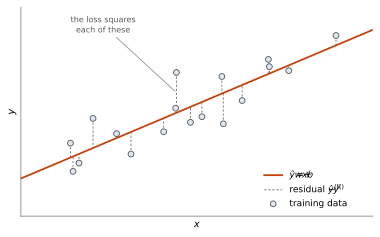

In [3]:
def linreg_residuals_figure():
    """The same fit, with the residual each point contributes to the loss."""
    rng = np.random.default_rng(3)
    x = np.sort(rng.uniform(0.4, 5.6, 18))
    y = 1.1 + 0.85 * x + rng.normal(0, 0.85, x.size)
    w, b = np.polyfit(x, y, 1)
    yhat = w * x + b

    fig, ax = plt.subplots(figsize=(5.4, 3.4))
    grid = np.linspace(0, 6, 2)
    ax.plot(grid, w * grid + b, color='#c1440e', linewidth=1.8, zorder=2,
            label='$ŷ = wx + b$')
    for xi, yi, yh in zip(x, y, yhat):
        ax.plot([xi, xi], [yi, yh], color='0.45', linewidth=0.9,
                linestyle=(0, (2.5, 2)), zorder=1)
    ax.plot([], [], color='0.45', linewidth=0.9, linestyle=(0, (2.5, 2)),
            label='residual $ŷ^{(i)} - y^{(i)}$')
    ax.scatter(x, y, s=34, facecolor='#dce7f2', edgecolor='0.35',
               linewidth=0.9, zorder=3, label='training data')

    # call out the single largest residual
    k = int(np.argmax(np.abs(y - yhat)))
    ax.annotate('the loss squares\neach of these',
                xy=(x[k], (y[k] + yhat[k]) / 2),
                xytext=(x[k] - 1.25, y.max() + 0.35),
                fontsize=8, color='0.35', ha='center', va='center',
                linespacing=1.4,
                arrowprops=dict(arrowstyle='-', color='0.55', linewidth=0.8))

    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    ax.set_xlim(0, 6)
    ax.set_ylim(y.min() - 1.5, y.max() + 0.95)
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(loc='lower right', frameon=False, fontsize=9)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
    for side in ('left', 'bottom'):
        ax.spines[side].set_color('0.5')
    fig.tight_layout()

linreg_residuals_figure()

Note that large differences between the estimates $\hat{y}^{(i)}$ and targets $y^{(i)}$
lead to large contributions to the loss
due to its quadratic form.
This quadratic dependence can be a double-edge sword; while it encourages the model to avoid large errors it can also lead to excessive sensitivity to anomalous data, i.e. outliers.


To measure the quality of a model on the entire dataset of $n$ examples,
we simply average (or equivalently, sum)
the losses on the training set:

$$L(\mathbf{w}, b) =\frac{1}{n}\sum_{i=1}^n l^{(i)}(\mathbf{w}, b) =\frac{1}{n} \sum_{i=1}^n \left(\mathbf{w}^\top \mathbf{x}^{(i)} + b - y^{(i)}\right)^2.$$

When training the model, we seek parameters ($\mathbf{w}^*, b^*$)
that minimize the total loss across all training examples:

$$\mathbf{w}^*, b^* = \operatorname*{argmin}_{\mathbf{w}, b}\  L(\mathbf{w}, b).$$

### An Analytical Solution

Unlike most of the models that we will cover,
linear regression presents us with
a surprisingly easy optimization problem.
In particular, we can find the optimal parameters
(as assessed on the training data)
analytically by applying a simple formula as follows.
First, we can subsume the bias $b$ into the parameter $\mathbf{w}$
by appending a column to the feature matrix consisting of all 1s.
With that notation, our objective is now to minimize

$$L(\mathbf{w}, b) =\frac{1}{n} \sum_{i=1}^n \left(\mathbf{w}^\top \mathbf{x}^{(i)} - y^{(i)}\right)^2.$$

Ignoring the constant $1/(n)$, we can equivalently seek to minimize

$$\|\mathbf{y} - \mathbf{X}\mathbf{w}\|^2,$$

where $||\mathbf{x}||^2$ is the norm of a vector $\mathbf{x}$ defined as:
$$
||\mathbf{x}||^2 = \mathbf{x}^\top \mathbf{x} = \sum_{i=1}^d x_i^2
$$

For some details about norms and dot products see [this notebook](https://github.com/asabenhur/CS345/blob/master/fall24/notebooks/module01_03_dot_products.ipynb).
As long as the design matrix $\mathbf{X}$ has full rank
(no feature is linearly dependent on the others),
then there will be just one critical point on the loss surface
and it corresponds to the minimum of the loss over the entire domain.

Taking the derivative of the loss with respect to $\mathbf{w}$
and setting it equal to zero yields:

$$
    \partial_{\mathbf{w}} \|\mathbf{y} - \mathbf{X}\mathbf{w}\|^2 =
    - 2 \mathbf{X}^\top (\mathbf{y} - \mathbf{X} \mathbf{w}) = 0,
$$
where $\partial_{\mathbf{w}}$ denotes differentiation with respect to the vector $\mathbf{w}$.

How did we get that?  We need a bit of a digression...

### The gradient

The **gradient** of a  multivariate function $f(w_1,\ldots,w_d)$ is the vector of partial derivatives
$$\partial_{\mathbf{w}} f(\mathbf{w}) =  
\begin{pmatrix}
\frac{\partial f(\mathbf{w})}{\partial w_1} \\
\vdots \\
\frac{\partial f(\mathbf{w})}{\partial w_d} 
\end{pmatrix}$$
An alternative notation to is $\frac{\partial f}{\partial \mathbf{w}}$ or $\nabla_{\mathbf{w}} f$.  

To help us compute the above derivative, let's first compute the gradient of a much simpler function, 

$$
f(\mathbf{w}) = \mathbf{w}^\top \mathbf{x} = \sum_{i=1}^d w_i x_i.
$$

This is easy:

$$
\frac{\partial f}{\partial w_i} = x_i .
$$

We can thus conclude that 

$$
\partial_{\mathbf{w}} f(\mathbf{w}) = \mathbf{x} .
$$

Next let's show that: 

$$
\partial_{\mathbf{w}} \mathbf{X} \mathbf{w}  =\mathbf{X}^\top .
$$

To see this let's consider
the derivative of a vector-valued function $f : \mathbb{R}^{d} \to \mathbb{R}^{n}$ which is the $d \times n$ matrix

$$
\left[ \partial_{\mathbf{w}} f \right]_{ij} = \frac{\partial f_j}{\partial w_i}.
$$

Writing the $j$-th component of $\mathbf{X}\mathbf{w}$ explicitly,

$$
(\mathbf{X}\mathbf{w})_j = \sum_{k=1}^{d} X_{jk} w_k ,
$$

and differentiating with respect to $w_i$ leaves only the $k = i$ term:

$$
\left[ \partial_{\mathbf{w}} \mathbf{X}\mathbf{w} \right]_{ij}
= \frac{\partial}{\partial w_i} \sum_{k=1}^{d} X_{jk} w_k
= X_{ji}.
$$


Using this result and an application of the chain rule will give us the claimed result that
$$
    \partial_{\mathbf{w}} \|\mathbf{y} - \mathbf{X}\mathbf{w}\|^2 =
    - 2 \mathbf{X}^\top (\mathbf{y} - \mathbf{X} \mathbf{w}) = 0,
$$

This in turn gives:

$$
\mathbf{X}^\top \mathbf{y} = \mathbf{X}^\top \mathbf{X} \mathbf{w}.
$$

Solving for $\mathbf{w}$ provides us with the optimal solution for the optimization problem.
Note that this solution 

$$\mathbf{w}^* = (\mathbf X^\top \mathbf X)^{-1}\mathbf X^\top \mathbf{y}$$

will only be unique
when the matrix $\mathbf X^\top \mathbf X$ is invertible,
i.e., when the columns of the feature matrix are linearly independent.

**Note.** For the matrix to be invertible we have to have $d\leq n$.  In the case $d > n$ we fewer equations than parameters, so we can fit the data exactly.

**Note.** An alternative way to compute the gradient of the loss function is to express $\|\mathbf{y} - \mathbf{X}\mathbf{w}\|^2$ as $(\mathbf{y} - \mathbf{X}\mathbf{w})^\top(\mathbf{y} - \mathbf{X}\mathbf{w})$, expanding all the terms and then computing the gradient.

**We got lucky**.  While simple problems like linear regression may admit analytic solutions,
you should not get used to such good fortune.
Although analytic solutions allow for nice mathematical analysis,
the requirement of an analytic solution is so restrictive
that it would exclude almost all exciting aspects of deep learning.

### When $\mathbf{X}^\top \mathbf{X}$ is close to singular

The statement that $\mathbf{w}^*$ is unique when the columns of $\mathbf{X}$ are linearly
independent is correct, but it invites a misleading picture in which a matrix is either
invertible or not, and everything is fine if the matrix is invertible.  Real feature matrices are
rarely exactly singular.  They are often *close to singular*, and near-singular matrices behave almost as badly.

Suppose two features $x_1$ and $x_2$ are highly correlated -- for example, the displacement of a
car's engine and its number of cylinders -- and suppose both have been standardized.  Consider what
happens if we change their coefficients in opposite directions.  For any $\delta$,

$$(w_1 + \delta)\,x_1 + (w_2 - \delta)\,x_2 \;=\; w_1 x_1 + w_2 x_2 \;+\; \delta\,(x_1 - x_2).$$

When the two features are highly correlated, $x_1 - x_2$ is small (because we standardized them), and so the predictions barely move.

Whatever value $w_2$ takes, there is an offsetting change in $w_1$ for which we get almost
the same predictions.  Instead of a single well-determined pair of coefficients we have a whole line
of pairs that fit almost equally well, and the training data has little to say about where along
that line the answer lies.  It cannot: both features are reporting on the same underlying quantity,
namely how big the car is.

In this case, while $\mathbf{X}^\top \mathbf{X}$ is technically invertible, there is a direction in weight space along which the loss is nearly flat, and along that direction the solution is very poorly
determined.

The quantity that measures how close we are to that situation is the **condition number**.  For a
symmetric positive definite matrix such as $\mathbf{X}^\top \mathbf{X}$, it is the ratio of the
largest to the smallest eigenvalue,

$$\kappa\!\left(\mathbf{X}^\top \mathbf{X}\right) = \frac{\lambda_{\max}}{\lambda_{\min}},$$

and for the feature matrix itself it is the ratio of the largest to the smallest singular value,
$\kappa(\mathbf{X}) = \sigma_{\max}/\sigma_{\min} = \sqrt{\kappa(\mathbf{X}^\top \mathbf{X})}$.
A matrix with $\kappa$ close to 1 is called **well-conditioned**; one with large $\kappa$ is
**ill-conditioned**.  An exactly singular matrix has $\lambda_{\min} = 0$ and $\kappa = \infty$, so
the condition number extends the notion of invertibility from a yes/no property to a matter of
degree.

For two features this can be worked out exactly.  If $x_1$ and $x_2$ are standardized and have
correlation $\rho$, then

$$\frac{1}{n}\mathbf{X}^\top \mathbf{X} = \begin{pmatrix} 1 & \rho \\ \rho & 1\end{pmatrix},$$

whose eigenvalues are $1 + \rho$ and $1 - \rho$.  The condition number is therefore

$$\kappa = \frac{1+\rho}{1-\rho}.$$

The two eigenvectors are the directions we looked at above: moving the coefficients in opposite
directions is the cheap one, with eigenvalue $1 - \rho$, and moving them together is the expensive
one, with eigenvalue $1 + \rho$.

| $\rho$ | 0 | 0.5 | 0.9 | 0.95 | 0.99 |
|---|---|---|---|---|---|
| $\kappa$ | 1 | 3 | 19 | 39 | 199 |

Uncorrelated features give $\kappa = 1$, the best possible.  The growth is slow at first and then
sudden: the difference between $\rho = 0.5$ and $\rho = 0.9$ matters far less than the difference
between $\rho = 0.99$ and $\rho = 0.999$.  This is why a correlation that looks merely "high" can
still leave a problem that is numerically fine, while one that looks only slightly higher does not.
Displacement and cylinders, our example above, are correlated at $\rho = 0.95$ in the dataset we will look at in a following notebook, giving $\kappa \approx 40$.

The above formula holds for two features.  With more features,
pairwise correlations no longer tell the whole story, because a feature can be nearly a combination
of *several* others while being only weakly correlated with each of them individually.  In that
situation the condition number can still be high without it showing up in pairwise feature correlations.

A nearly flat direction has a second consequence, which follows from the first.  If the loss barely
distinguishes between two candidate solutions, then only a small change in the data is needed to
prefer one over the other -- and since the flat direction is a long one, that small change can move
the solution a long way along it.  Poorly determined and highly sensitive are two descriptions of the
same situation, and $\kappa$ measures both.

Note that a high condition number does not imply that the coefficients are unstable under arbitrary perturbations of the data.
Most perturbations are harmless, because they have little component along the flat direction.  What a
high condition number guarantees is the *existence* of perturbation directions under which the
coefficients are highly sensitive -- and along those directions the amplification can be as large as
$\kappa$ itself.  Ill-conditioning is a statement about the worst case rather than the typical one.

That is quite bad enough, because we do not get to choose the direction.  Noise in the labels,
measurement error in the features, and -- as we will see -- floating-point rounding all supply
perturbations we do not control, and a perturbation spread over all directions has some component
along the dangerous one.  This is the origin of the rule of thumb that a problem with
$\kappa \approx 10^{k}$ costs roughly $k$ significant digits of accuracy in the computed solution.

This one number turns out to govern three things we care about, and it will come back in each of the
next few notebooks:

| consequence | where |
|---|---|
| how far gradient descent's answer sits from the analytic one | the next notebooks, on the auto-mpg data |
| how badly a model overfits as we add features | generalization and overfitting |
| how much regularization helps, and why | weight decay |

It also governs how *quickly* gradient descent converges, which is what motivates momentum later in
the course.

### Solving Linear Regression with Gradient Descent

Fortunately, even in cases where we cannot solve models analytically,
we can still usually train them effectively in practice.
The key technique for optimizing nearly every deep learning model,
and which we will call upon throughout this book,
consists of iteratively reducing the error
by updating the parameters in the direction
that incrementally lowers the loss function.
This algorithm is called **gradient descent**.
Gradient descent is used to find the minimum of a multi-variate function by iteratively following the gradient.  

Given a function $J(\mathbf{w})$, the gradient is the direction of steepest ascent.
Therefore to minimize $J(\mathbf{w})$, we iteratively take small steps in the direction of the negative of the gradient.

Gradient descent is an iterative algorithm as follows:

* Initialize $\mathbf{w}(0),\eta$.
* for $t = 0,1,\ldots$
  * $\mathbf{w}(t+1) = \mathbf{w}(t) - \eta \frac{\partial J}{\partial \mathbf{w}}$
  * if converged, break
  
The halting condition for the algorithm can be specified in terms of the number of epochs, or in terms of convergence of the loss function.  In other words, if there is little change of the loss function across epochs.

The following is an illustration of the gradient of the function $f(\mathbf{w})=||\mathbf{w}||^2$:

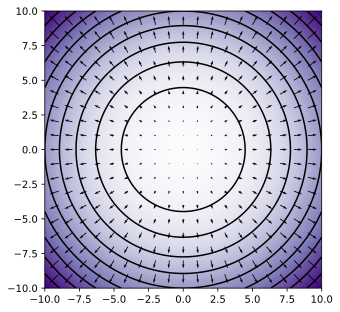

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, y) :
    return x**2 + y**2

x = np.arange(-10, 10, 1)
y = np.arange(-10, 10, 1)

x_dense = np.linspace(-10, 10, 500)
y_dense = np.linspace(-10, 10, 500)

X, Y = np.meshgrid(x_dense, y_dense)
U, V = np.meshgrid(2*x, 2*y)

Z = f(X, Y)

plt.figure(figsize=(5,5))
C = plt.contour(x_dense, y_dense, Z, 10, colors='black')

q = plt.quiver(x, y, U, V)

im = plt.imshow(Z, origin='lower',
                cmap=plt.cm.Purples, extent=(-10,10,-10,10) )


### Minibatch Stochastic Gradient Descent

The most naive application of gradient descent
consists of taking the derivative of the loss function,
which is an average of the losses computed
on every single example in the dataset.
In practice, this can be extremely slow:
we must pass over the entire dataset before making a single update.
Even worse, if there is a lot of redundancy in the training data, the benefit of a full update is limited.

The other extreme is to consider only a single example at a time and to take
update steps based on one observation at a time.
The resulting algorithm, **stochastic gradient descent** (SGD)
can be an effective strategy, even for large datasets.
Unfortunately, SGD has drawbacks, both computational and statistical.
One problem arises from the fact that processors are a lot faster
multiplying and adding numbers than they are
at moving data from main memory to processor cache.
It is up to an order of magnitude more efficient to
perform a matrix--vector multiplication
than a corresponding number of vector--vector operations.
This means that it can take a lot longer to process
one sample at a time compared to a batch of samples.
A second problem is that some of the layers,
such as batch normalization (to be described later),
only work well when we have access
to more than one observation at a time.

The solution to both problems is to pick an intermediate strategy:
rather than look at the entire dataset (i.e. full batch) or only a single sample at a time,
we take a **minibatch** of observations.
The specific choice of the size of the said minibatch depends on many factors,
such as the amount of memory, the number of GPUs,
the choice of layers, and the total dataset size.
Despite all that, a number between 32 and 256,
preferably a multiple of a large power of $2$, is a good start.
This leads us to **minibatch stochastic gradient descent**.

In its most basic form, in each iteration $t$,
we first randomly sample a minibatch $\mathcal{B}_t$
consisting of a fixed number $|\mathcal{B}|$ of training examples.
We then compute the derivative (gradient) of the average loss
on the minibatch with respect to the model parameters.
Finally, we multiply the gradient
by a predetermined small positive value $\eta$,
called the **learning rate**,
and subtract the resulting term from the current parameter values.
We can express the update as follows:

$$(\mathbf{w},b) \leftarrow (\mathbf{w},b) - \frac{\eta}{|\mathcal{B}|} \sum_{i \in \mathcal{B}_t} \partial_{(\mathbf{w},b)} l^{(i)}(\mathbf{w},b).$$

In summary, minibatch SGD proceeds as follows:

1. Initialize the values of the model parameters, typically at random
2. Iteratively sample random minibatches from the data,
updating the parameters in the direction of the negative gradient.

For the quadratic loss and affine transformations,
this has a closed-form expression:

$$\begin{aligned} \mathbf{w} & \leftarrow \mathbf{w} - \frac{2\eta}{|\mathcal{B}|} \sum_{i \in \mathcal{B}_t} \partial_{\mathbf{w}} l^{(i)}(\mathbf{w}, b) && = \mathbf{w} - \frac{2\eta}{|\mathcal{B}|} \sum_{i \in \mathcal{B}_t} \mathbf{x}^{(i)} \left(\mathbf{w}^\top \mathbf{x}^{(i)} + b - y^{(i)}\right)\\ b &\leftarrow b -  \frac{2\eta}{|\mathcal{B}|} \sum_{i \in \mathcal{B}_t} \partial_b l^{(i)}(\mathbf{w}, b) &&  = b - \frac{2\eta}{|\mathcal{B}|} \sum_{i \in \mathcal{B}_t} \left(\mathbf{w}^\top \mathbf{x}^{(i)} + b - y^{(i)}\right). \end{aligned}$$

The factor of $2$ in these expressions comes from differentiating the squared error $\left(\hat{y}^{(i)} - y^{(i)}\right)^2$; it is absent in the general update rule above because that rule is written for a generic per-example loss $l^{(i)}$. In practice this constant is often absorbed into the learning rate $\eta$, which is why you will frequently see the update written without it.

Since we pick a minibatch $\mathcal{B}$
we need to normalize by its size $|\mathcal{B}|$.

Frequently minibatch size and learning rate are user-defined.
Such tunable parameters that are not updated in the training loop are called **hyperparameters**.
They can be tuned automatically by a number of techniques, such as Bayesian optimization. In the end, the quality of the solution is
typically assessed on a separate *validation set*.


Note that even if our function is truly linear and noiseless,
the parameters learned by minibatch SGD  parameters will not be the exact minimizers of the loss, and will vary each time you apply the algorithm.
Although the algorithm converges slowly towards the minimizers
it typically will not find them exactly in a finite number of steps.

Linear regression happens to be a learning problem
with a global minimum (whenever $\mathbf{X}$ is full rank, or equivalently,
whenever $\mathbf{X}^\top \mathbf{X}$ is invertible).
However, the loss surfaces for deep networks contain many saddle points and minima.
Fortunately, we typically do not care about finding
an exact set of parameters but merely any set of parameters
that leads to accurate predictions (and thus low loss).
In practice, deep learning practitioners
seldom struggle to find parameters
that minimize the loss *on training sets*.
The more formidable task is to find parameters
that lead to accurate predictions on previously unseen data,
i.e. lead to good *generalization*.
We return to these topics throughout the book.


### Making Predictions

Given the model $\mathbf{w}^\top \mathbf{x} + b$,
we can now make *predictions* for a new example,
e.g., predicting the sales price of a previously unseen house
given its area $x_1$ and distance $x_2$.
Deep learning practitioners have taken to calling the prediction phase *inference*
but this is a bit of a misnomer---*inference* refers broadly
to any conclusion reached on the basis of evidence,
including both the values of the parameters
and the likely label for an unseen instance.
If anything, in the statistics literature
*inference* more often denotes parameter inference
and this overloading of terminology creates unnecessary confusion
when deep learning practitioners talk to statisticians.
In the following we will stick to *prediction* whenever possible.



## The Normal Distribution and the Squared Loss

So far we have given a fairly functional motivation
of the squared loss objective.
We can also provide a more formal motivation for the squared loss objective
by making probabilistic assumptions
about the distribution of noise.

Linear regression was invented at the turn of the 19th century.
While it has long been debated whether Gauss or Legendre
first thought up the idea,
it was Gauss who also discovered the normal distribution
(also called the *Gaussian*).
It turns out that the normal distribution
and linear regression with squared loss
share a deeper connection than common parentage.

To begin, recall that a normal distribution
with mean $\mu$ and variance $\sigma^2$ (standard deviation $\sigma$)
is given by:

$$p(x) = \frac{1}{\sqrt{2 \pi \sigma^2}} \exp\left(-\frac{1}{2 \sigma^2} (x - \mu)^2\right).$$

And in code:

In [5]:
def normal(x, mu, sigma):
    p = 1 / math.sqrt(2 * math.pi * sigma**2)
    return p * np.exp(-0.5 * (x - mu)**2 / sigma**2)

We can now visualize the normal distribution:


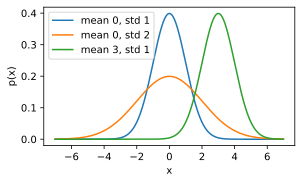

In [6]:
x = np.arange(-7, 7, 0.01)

# Mean and standard deviation pairs
params = [(0, 1), (0, 2), (3, 1)]
plt.figure(figsize=(4.5, 2.5))
for (mu, sigma) in params:
    plt.plot(x, normal(x, mu, sigma), label=f'mean {mu}, std {sigma}')
plt.legend()
plt.xlabel('x')
plt.ylabel('p(x)');


Note that changing the mean corresponds
to a shift along the $x$-axis,
and increasing the variance
spreads the distribution out,
lowering its peak.

One way to motivate linear regression with squared loss
is to assume that observations arise from noisy measurements,
where the noise $\epsilon$ follows the normal distribution 
$\mathcal{N}(0, \sigma^2)$:

$$y = \mathbf{w}^\top \mathbf{x} + b + \epsilon \textrm{ where } \epsilon \sim \mathcal{N}(0, \sigma^2).$$

Thus, we can now write out the *likelihood*
of seeing a particular $y$ for a given $\mathbf{x}$ via

$$P(y \mid \mathbf{x}) = \frac{1}{\sqrt{2 \pi \sigma^2}} \exp\left(-\frac{1}{2 \sigma^2} (y - \mathbf{w}^\top \mathbf{x} - b)^2\right).$$

According to *the principle of maximum likelihood*,
the best values of parameters $\mathbf{w}$ and $b$ are those
that maximize the *likelihood* of the model predictions:

$$P(\mathbf y \mid \mathbf X) = \prod_{i=1}^{n} p(y^{(i)} \mid \mathbf{x}^{(i)}).$$

The likelihood factors as a product since all pairs $(\mathbf{x}^{(i)}, y^{(i)})$
were drawn independently of each other.
Estimators chosen according to the principle of maximum likelihood
are called *maximum likelihood estimators*.
While maximizing the product of many exponential functions
might look difficult,
we can simplify things significantly, without changing the objective,
by maximizing the logarithm of the likelihood instead (aka log-likelihood).
For historical reasons, optimizations are more often expressed
as minimization rather than maximization.
So, without changing anything,
we can *minimize* the *negative log-likelihood*,
which we can express as follows:

$$-\log P(\mathbf y \mid \mathbf X) = \sum_{i=1}^n \left( \frac{1}{2} \log(2 \pi \sigma^2) + \frac{1}{2 \sigma^2} \left(y^{(i)} - \mathbf{w}^\top \mathbf{x}^{(i)} - b\right)^2\right).$$

Since $\sigma$ is fixed,
we can ignore the first term,
because it does not depend on $\mathbf{w}$ or $b$.
The second term is identical
to the squared error loss introduced earlier,
except for the multiplicative constant $\frac{1}{\sigma^2}$.
Fortunately, the solution does not depend on $\sigma$ either.
It follows that **minimizing the mean squared error
is equivalent to the maximum likelihood estimation
of a linear model under the assumption of additive Gaussian noise**.



## Linear Regression as a Neural Network

Next, we will show how we can express linear regression as a simple (artificial) neural network.  But first let's take a look at the biology of neurons.

### Biology

Because linear regression predates computational neuroscience,
it might seem anachronistic to describe
linear regression in terms of neural networks.
Nonetheless, they were a natural place to start
when the cyberneticists and neurophysiologists
Warren McCulloch and Walter Pitts began to develop
models of artificial neurons.
Consider the cartoonish picture
of a biological neuron shown below,
consisting of *dendrites* (input terminals),
the *nucleus* (CPU), the *axon* (output wire),
and the *axon terminals* (output terminals),
enabling connections to other neurons via *synapses*.

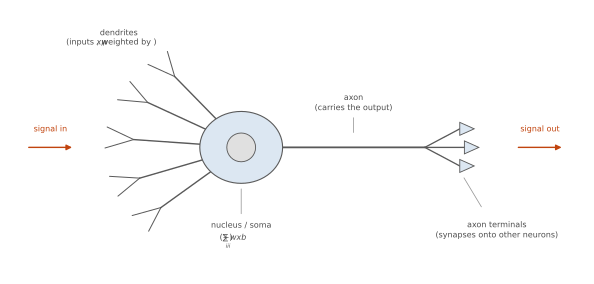

In [7]:
def biological_neuron_figure():
    """A schematic neuron: dendrites in, soma, axon, terminals out."""
    from matplotlib.patches import FancyArrowPatch, Circle, Ellipse, Polygon

    body, edge, grey, red = '#dce7f2', '0.35', '0.45', '#c1440e'
    fig, ax = plt.subplots(figsize=(8.05, 3.75))

    soma_x, soma_y = 0.0, 0.0
    ax.add_patch(Ellipse((soma_x, soma_y), 1.15, 1.0, facecolor=body,
                         edgecolor=edge, linewidth=1.1, zorder=3))
    ax.add_patch(Circle((soma_x, soma_y), 0.20, facecolor='0.88',
                        edgecolor=edge, linewidth=0.9, zorder=4))

    # dendrites: branches entering the soma from the left
    for ang in (150, 175, 200, 128, 222):
        a = np.radians(ang)
        x0, y0 = soma_x + 0.5 * np.cos(a), soma_y + 0.45 * np.sin(a)
        x1, y1 = soma_x + 1.5 * np.cos(a), soma_y + 1.25 * np.sin(a)
        ax.plot([x0, x1], [y0, y1], color=edge, linewidth=1.4,
                solid_capstyle='round', zorder=2)
        for spread in (-24, 24):
            b = np.radians(ang + spread)
            ax.plot([x1, x1 + 0.42 * np.cos(b)], [y1, y1 + 0.36 * np.sin(b)],
                    color=edge, linewidth=1.0, solid_capstyle='round', zorder=2)

    # the axon
    axon_x0, axon_x1 = soma_x + 0.57, 2.55
    ax.plot([axon_x0, axon_x1], [0, 0], color=edge, linewidth=1.8,
            solid_capstyle='round', zorder=2)

    # axon terminals
    for ang in (28, 0, -28):
        a = np.radians(ang)
        x1, y1 = axon_x1 + 0.55 * np.cos(a), 0.55 * np.sin(a)
        ax.plot([axon_x1, x1], [0, y1], color=edge, linewidth=1.3,
                solid_capstyle='round', zorder=2)
        ax.add_patch(Polygon([[x1, y1 - 0.09], [x1, y1 + 0.09],
                              [x1 + 0.20, y1]], closed=True, facecolor=body,
                             edgecolor=edge, linewidth=0.9, zorder=3))

    labels = [(-1.70, 1.52, 'dendrites\n(inputs $x_i$, weighted by $w_i$)', 'center'),
              (0.0, -1.22, 'nucleus / soma\n($\\sum_i w_i x_i + b$)', 'center'),
              (1.56, 0.62, 'axon\n(carries the output)', 'center'),
              (3.55, -1.15, 'axon terminals\n(synapses onto other neurons)', 'center')]
    for x, y, text, ha in labels:
        ax.text(x, y, text, ha=ha, va='center', fontsize=8, color='0.3',
                linespacing=1.4)

    ax.annotate('', xy=(0.0, -0.55), xytext=(0.0, -0.95),
                arrowprops=dict(arrowstyle='-', color='0.6', linewidth=0.8))
    ax.annotate('', xy=(1.56, 0.18), xytext=(1.56, 0.44),
                arrowprops=dict(arrowstyle='-', color='0.6', linewidth=0.8))
    ax.annotate('', xy=(3.08, -0.40), xytext=(3.35, -0.85),
                arrowprops=dict(arrowstyle='-', color='0.6', linewidth=0.8))

    ax.add_patch(FancyArrowPatch((-2.95, 0.0), (-2.35, 0.0), arrowstyle='-|>',
                                 mutation_scale=11, linewidth=1.4, color=red,
                                 shrinkA=0, shrinkB=0, zorder=4))
    ax.text(-2.65, 0.20, 'signal in', ha='center', va='bottom', fontsize=8,
            color=red)
    ax.add_patch(FancyArrowPatch((3.85, 0.0), (4.45, 0.0), arrowstyle='-|>',
                                 mutation_scale=11, linewidth=1.4, color=red,
                                 shrinkA=0, shrinkB=0, zorder=4))
    ax.text(4.15, 0.20, 'signal out', ha='center', va='bottom', fontsize=8,
            color=red)

    ax.set_xlim(-3.25, 4.80)
    ax.set_ylim(-1.80, 1.95)
    ax.set_aspect('equal')
    ax.axis('off')
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)

biological_neuron_figure()

Information $x_i$ arriving from other neurons
(or environmental sensors) is received in the dendrites.
In particular, that information is weighted
by *synaptic weights* $w_i$,
determining the effect of the inputs,
e.g., activation or inhibition via the product $x_i w_i$.
The weighted inputs arriving from multiple sources
are aggregated in the nucleus
as a weighted sum $y = \sum_i x_i w_i + b$,
possibly subject to some nonlinear postprocessing via a function $\sigma(y)$.
This information is then sent via the axon to the axon terminals,
where it reaches its destination
(e.g., an actuator such as a muscle) or it is fed into another neuron via its dendrites.

### From Biological to Artificial Neural Networks

With that in mind, we can express linear regression using the following simple neural "network":

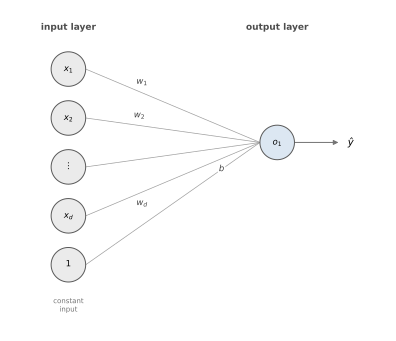

In [8]:
def _fc_network(ax, in_labels, out_labels, x_in=0.0, x_out=2.6, r=0.30,
                dy=0.95, dy_out=None, in_fill='0.92', out_fill='#dce7f2',
                edge_color='0.62', edge_lw=0.7):
    """A fully connected layer: every input circle joined to every output."""
    from matplotlib.patches import Circle

    dy_out = dy if dy_out is None else dy_out
    n_in, n_out = len(in_labels), len(out_labels)
    y_in = [(n_in - 1) / 2 * dy - i * dy for i in range(n_in)]
    y_out = [(n_out - 1) / 2 * dy_out - i * dy_out for i in range(n_out)]

    for yi in y_in:
        for yo in y_out:
            ax.plot([x_in + r, x_out - r], [yi, yo], color=edge_color,
                    linewidth=edge_lw, zorder=1)
    for y, label in zip(y_in, in_labels):
        ax.add_patch(Circle((x_in, y), r, facecolor=in_fill, edgecolor='0.35',
                            linewidth=1.0, zorder=3))
        ax.text(x_in, y, label, ha='center', va='center', fontsize=8.5, zorder=4)
    for y, label in zip(y_out, out_labels):
        ax.add_patch(Circle((x_out, y), r, facecolor=out_fill, edgecolor='0.35',
                            linewidth=1.0, zorder=3))
        ax.text(x_out, y, label, ha='center', va='center', fontsize=8.5, zorder=4)
    return y_in, y_out

def _bias_node(ax, x_in, y, x_out, y_out, labels, r=0.30, fill='0.92',
               edge_color='0.62', edge_lw=0.7, t=0.78):
    """The bias as a constant input.

    One more node in the input layer, permanently equal to 1.  Its edges are
    ordinary edges, so the bias is just the weight on each of them — the same
    story the $w$'s tell.
    """
    from matplotlib.patches import Circle

    for yo, label in zip(y_out, labels):
        x0, x1 = x_in + r, x_out - r
        ax.plot([x0, x1], [y, yo], color=edge_color, linewidth=edge_lw,
                zorder=1)
        ax.text(x0 + t * (x1 - x0), y + t * (yo - y), label, ha='center',
                va='center', fontsize=8.5, color='0.25', zorder=5,
                bbox=dict(boxstyle='round,pad=0.12', facecolor='white',
                          edgecolor='none'))
    ax.add_patch(Circle((x_in, y), r, facecolor=fill, edgecolor='0.35',
                        linewidth=1.0, zorder=3))
    ax.text(x_in, y, '$1$', ha='center', va='center', fontsize=8.5, zorder=4)
    ax.text(x_in, y - r - 0.22, 'constant\ninput', ha='center', va='top',
            fontsize=7, color='0.45', linespacing=1.3)

def single_neuron_figure():
    """Linear regression drawn as a one-output, single-layer network."""
    from matplotlib.patches import FancyArrowPatch

    in_labels = ['$x_1$', '$x_2$', r'$\vdots$', '$x_d$']
    edge_labels = ['$w_1$', '$w_2$', '', '$w_d$']
    fig, ax = plt.subplots(figsize=(5.30, 4.54))
    x_in, x_out, r, dy = 0.0, 2.9, 0.24, 0.68
    y_in, y_out = _fc_network(ax, in_labels, ['$o_1$'], x_in, x_out, r, dy)

    # the weight rides on its own edge, offset just clear of the line
    yo = y_out[0]
    for yi, label in zip(y_in, edge_labels):
        if not label:
            continue
        x0, x1 = x_in + r, x_out - r
        t = 0.30
        xm, ym = x0 + t * (x1 - x0), yi + t * (yo - yi)
        dx, dy_ = x1 - x0, yo - yi
        n = np.hypot(dx, dy_)
        s = 0.14 if yi > yo else -0.14      # always on the outside of the fan
        ax.text(xm - s * dy_ / n, ym + s * dx / n, label, ha='center',
                va='center', fontsize=8.5, color='0.25', zorder=5,
                bbox=dict(boxstyle='round,pad=0.12', facecolor='white',
                          edgecolor='none'))

    y_bias = min(y_in) - dy
    _bias_node(ax, x_in, y_bias, x_out, y_out, ['$b$'], r=r)

    ax.add_patch(FancyArrowPatch((x_out + r, yo), (x_out + 0.85, yo),
                                 arrowstyle='-|>', mutation_scale=10,
                                 linewidth=1.0, color='0.45', shrinkA=0,
                                 shrinkB=0, zorder=2))
    ax.text(x_out + 0.98, yo, '$ŷ$', ha='left', va='center', fontsize=10)

    top = max(y_in) + r
    ax.text(x_in, top + 0.34, 'input layer', ha='center', va='center',
            fontsize=9, fontweight='bold', color='0.3')
    ax.text(x_out, top + 0.34, 'output layer', ha='center', va='center',
            fontsize=9, fontweight='bold', color='0.3')

    ax.set_xlim(x_in - 0.85, x_out + 1.55)
    ax.set_ylim(y_bias - r - 0.72, top + 0.62)
    ax.set_aspect('equal')
    ax.axis('off')
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)

single_neuron_figure()

The inputs are $x_1, \ldots, x_d$.
We refer to $d$ as the *number of inputs*
or the *feature dimensionality* in the input layer.
The output of the network is $o_1$.
Because we are just trying to predict
a single numerical value,
we have only one output neuron.
Note that the input values are all *given*.
There is just a single *computed* neuron.
In summary, we can think of linear regression
as a single-layer fully connected neural network.
We will encounter networks
with far more layers
in later chapters.


Certainly, the high-level idea that many such units
could be combined, provided they have the appropriate connectivity and learning algorithm,
to produce far more interesting and complex behavior
than any one neuron alone could express arises from our study of real biological neural systems.
At the same time, most research in deep learning today
draws inspiration from a much wider source including
mathematics, linguistics, psychology,
statistics, computer science, and other fields.

## Summary

In this notebook, we introduced
traditional linear regression,
where the parameters of a linear function
are chosen to minimize the squared loss on the training set.
We motivated this choice of objective through an interpretation
of linear regression as maximimum likelihood estimation
under an assumption of linearity and Gaussian noise.
After discussing both computational considerations
and connections to statistics,
we showed how such linear models can be expressed
as simple neural networks where the inputs
are directly connected to the output.
While we will soon move past linear models altogether,
they are a good way to introduce most of the components
that all of our models require:
parametric forms, a differentiable objective,
optimization via minibatch stochastic gradient descent,
and ultimately, evaluation on previously unseen data.